### **Install libraries before running the code**
- pip install pandas
- pip install numpy
- pip install matplotlib
- pip install seaborn
- pip install scikit-learn

# **Main Code**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler , StandardScaler
from sklearn.model_selection import train_test_split
from numpy import hstack
import time
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, MiniBatchKMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics import silhouette_samples
from sklearn.cluster import DBSCAN
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

## Mall Customer Segmentation Data

In [ ]:
import pandas as pd
mall_df=pd.read_csv("Mall_Customers.csv")
mall_df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


Reading the dataset and making sure there is no missing values

In [ ]:
print(mall_df.shape)
print("------------------------")
print(mall_df.info())
#This makes sure that we dont have any textual data(attributes) to encode
print("------------------------")
print("The sum of null values in this dataset = ",mall_df.isnull().sum())
#This makes sure that we dont have any null values to impute
print("------------------------")
print("The number of null values :\n",mall_df.isnull().sum())
print("------------------------")
print("The number of duplicated rows:\n",mall_df.duplicated().sum())

(200, 5)
------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None
------------------------
The sum of null values in this dataset =  CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64
------------------------
The number of null values :
 CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64
----------------

In [ ]:
# dropping CustomerID column because its not useful
mall_df=mall_df.drop(["CustomerID"],axis=1)

Encoding cartagorical features

In [ ]:
le=LabelEncoder()
mall_df["Gender"]=le.fit_transform(mall_df["Gender"])

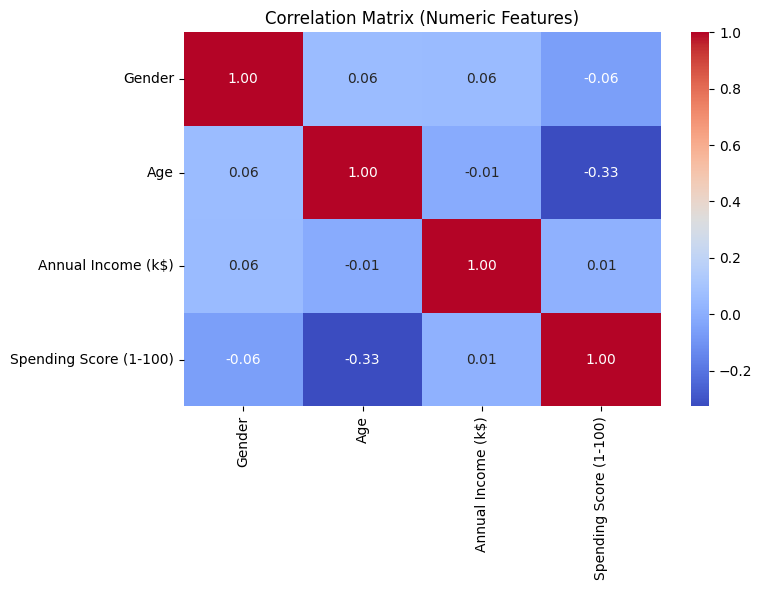

In [ ]:
corr_matrix=mall_df.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix (Numeric Features)")
plt.tight_layout()
plt.show()

This heatmap shows the relationship between the numeric features which will help us with feature extraction

Feature Engineering:\
(adding a feature):

In [ ]:
mall_df["Income_per_age"]=mall_df["Annual Income (k$)"]/mall_df["Age"]
mall_df["Spending_per_Age"]=mall_df["Spending Score (1-100)"]/mall_df["Age"]
mall_df["Spending_per_Income"]=mall_df["Spending Score (1-100)"]/mall_df["Annual Income (k$)"]

In [ ]:
mall_df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100),Income_per_age,Spending_per_Age,Spending_per_Income
0,1,19,15,39,0.789474,2.052632,2.600000
1,1,21,15,81,0.714286,3.857143,5.400000
2,0,20,16,6,0.800000,0.300000,0.375000
3,0,23,16,77,0.695652,3.347826,4.812500
4,0,31,17,40,0.548387,1.290323,2.352941


**Before fixing skewness**

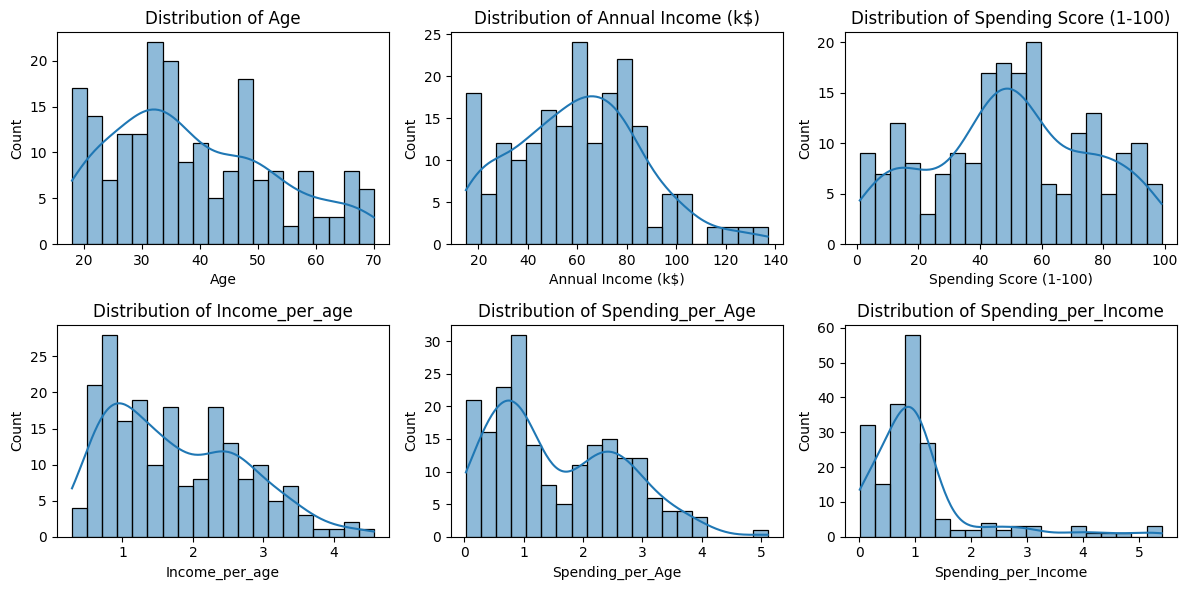

In [ ]:
columns =mall_df.columns[1:]
num_col=len(columns)

plt.figure(figsize=(12, 6))
for i, col in enumerate(columns, 1):
    plt.subplot(2, 3, i)
    sns.histplot(mall_df[col], kde=True, bins=20)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel("Count")
plt.tight_layout()
plt.show()

**After fixing skewness**

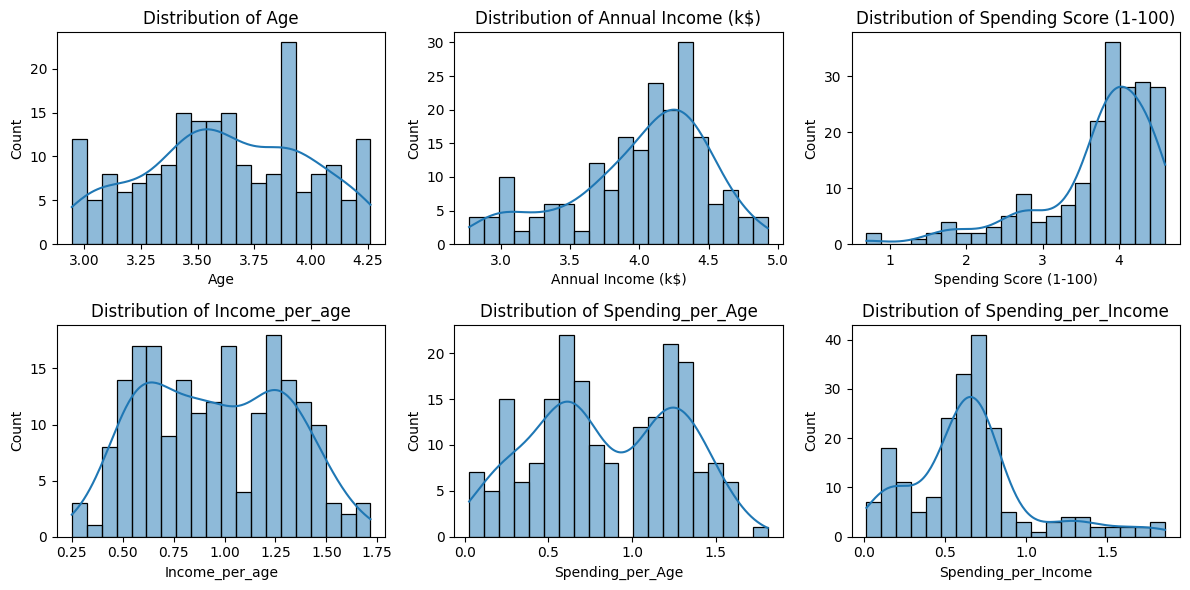

In [ ]:
# Applying log transformation
mall_df[columns] = np.log1p(mall_df[columns])

plt.figure(figsize=(12, 6))
for i, col in enumerate(columns, 1):
    plt.subplot(2, 3, i)
    sns.histplot(mall_df[col], kde=True, bins=20)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel("Count")
plt.tight_layout()
plt.show()

Box Plots for every feature for visualization

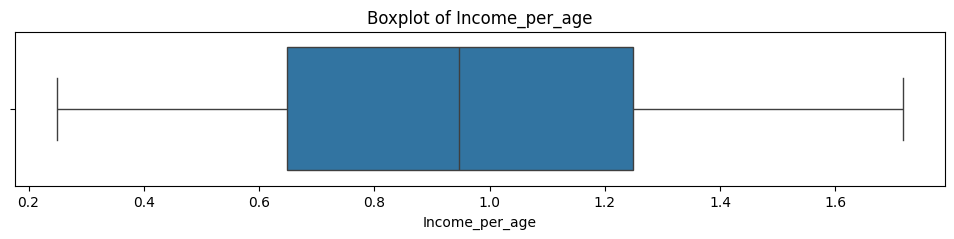

In [ ]:
plt.figure(figsize=(12,2))
sns.boxplot(x=mall_df['Income_per_age'])
plt.title("Boxplot of Income_per_age")
plt.xlabel("Income_per_age")
plt.show()

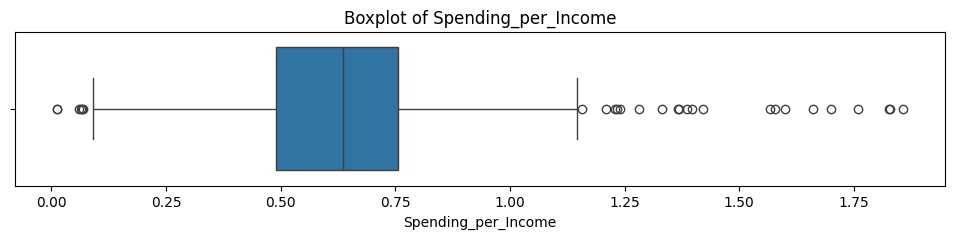

In [ ]:
plt.figure(figsize=(12,2))
sns.boxplot(x=mall_df['Spending_per_Income'])
plt.title("Boxplot of Spending_per_Income")
plt.xlabel("Spending_per_Income")
plt.show()

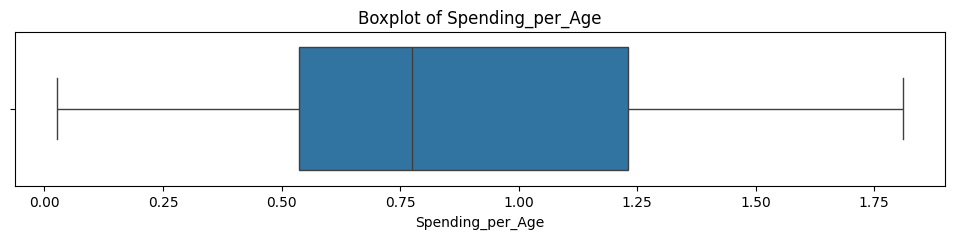

In [ ]:
plt.figure(figsize=(12,2))
sns.boxplot(x=mall_df['Spending_per_Age'])
plt.title("Boxplot of Spending_per_Age")
plt.xlabel("Spending_per_Age")
plt.show()

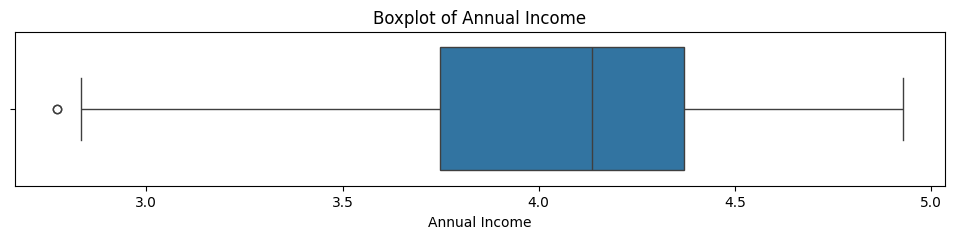

In [ ]:
plt.figure(figsize=(12,2))
sns.boxplot(x=mall_df['Annual Income (k$)'])
plt.title("Boxplot of Annual Income")
plt.xlabel("Annual Income")
plt.show()

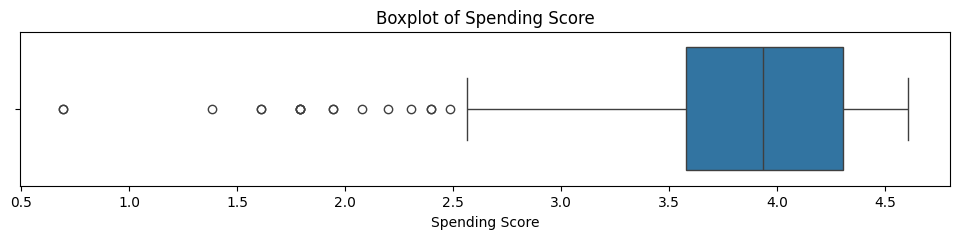

In [ ]:
plt.figure(figsize=(12,2))
sns.boxplot(x=mall_df['Spending Score (1-100)'])
plt.title("Boxplot of Spending Score")
plt.xlabel("Spending Score")
plt.show()

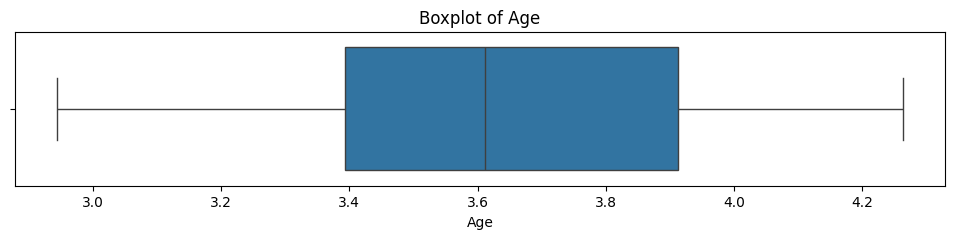

In [ ]:
plt.figure(figsize=(12,2))
sns.boxplot(x=mall_df['Age'])
plt.title("Boxplot of Age")
plt.xlabel("Age")
plt.show()

In [ ]:
Before_scaling=mall_df.copy()

Seperating Gender from other features for differant imputation methods

In [ ]:
n_col=['Age','Annual Income (k$)','Spending Score (1-100)','Spending_per_Age','Spending_per_Income','Income_per_age']
g_col = ['Gender']

In [ ]:
# Imputing all features with the mean exept for Gender
imputer = SimpleImputer(strategy="mean")
mall_df[n_col]=imputer.fit_transform(mall_df[n_col])
mall_df[n_col]= pd.DataFrame(mall_df[n_col])
mall_df[n_col].head()

,Age,Annual Income (k$),Spending Score (1-100),Spending_per_Age,Spending_per_Income,Income_per_age
0,2.995732,2.772589,3.688879,1.116004,1.280934,0.581922
1,3.091042,2.772589,4.406719,1.580450,1.856298,0.538997
2,3.044522,2.833213,1.945910,0.262364,0.318454,0.587787
3,3.178054,2.833213,4.356709,1.469676,1.760011,0.528067
4,3.465736,2.890372,3.713572,0.828693,1.209838,0.437214


In [ ]:
# Using most_frequent for Gender
imputer2=SimpleImputer(strategy="most_frequent")
mall_df[g_col]=imputer2.fit_transform(mall_df[g_col])
mall_df[g_col]= pd.DataFrame(mall_df[g_col])
mall_df[g_col].head()
mall_df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100),Income_per_age,Spending_per_Age,Spending_per_Income
0,1,2.995732,2.772589,3.688879,0.581922,1.116004,1.280934
1,1,3.091042,2.772589,4.406719,0.538997,1.580450,1.856298
2,0,3.044522,2.833213,1.945910,0.587787,0.262364,0.318454
3,0,3.178054,2.833213,4.356709,0.528067,1.469676,1.760011
4,0,3.465736,2.890372,3.713572,0.437214,0.828693,1.209838


**Scaling the data**

In [ ]:
scaler=StandardScaler()
mall_df_scalled=scaler.fit_transform(mall_df)

**Applying PCA:**

In [ ]:
pca= PCA(n_components=0.95)
x_pca= pca.fit_transform(mall_df_scalled)
num_components = pca.n_components_
print(f"Number of components to retain 95% variance: {num_components}")

Number of components to retain 95% variance: 4


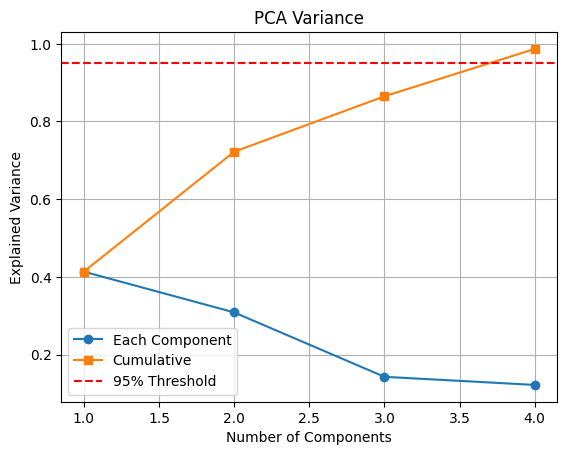

--------------------------------
components to reach 95% variance: 4


In [ ]:
explained_var = pca.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

plt.plot(range(1, num_components + 1), explained_var, marker='o', label='Each Component')
plt.plot(range(1, num_components + 1), cumulative_var, marker='s', label='Cumulative')
plt.axhline(y=0.95, color='r', linestyle='--', label='95% Threshold')

plt.title("PCA Variance")
plt.xlabel("Number of Components")
plt.ylabel("Explained Variance")
plt.grid()
plt.legend()
plt.show()

print("--------------------------------")
print("components to reach 95% variance:", np.argmax(cumulative_var >= 0.95) + 1)
# It returns the first argument that crosses the threshold + 1

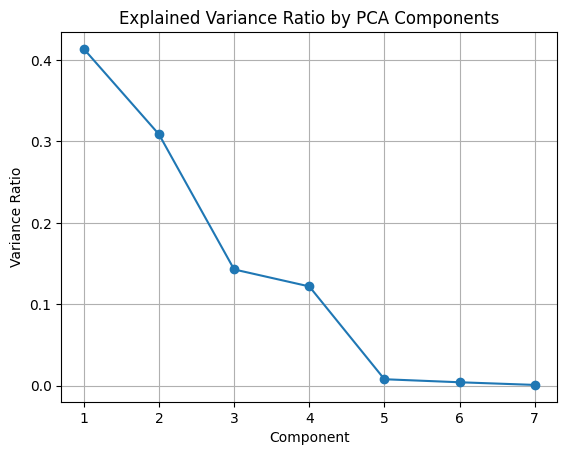

Explained variance ratios: [0.41351007 0.30861604 0.14278031 0.12191737 0.00795884 0.00423734
 0.00098002]
-------------------------------------------------
Cumulative explained variance: [0.41351007 0.72212612 0.86490643 0.9868238  0.99478264 0.99901998
 1.        ]


In [ ]:
pca_var = PCA(n_components=7)
pca_var.fit(mall_df_scalled)

explained_var = pca_var.explained_variance_ratio_

plt.plot(range(1, 8), explained_var, marker='o')
plt.title("Explained Variance Ratio by PCA Components")
plt.xlabel("Component")
plt.ylabel("Variance Ratio")
plt.grid(True)
plt.show()

print("Explained variance ratios:", explained_var)
print("-------------------------------------------------")
print("Cumulative explained variance:", np.cumsum(explained_var))


**2D PCA before and after scaling (visualization):**

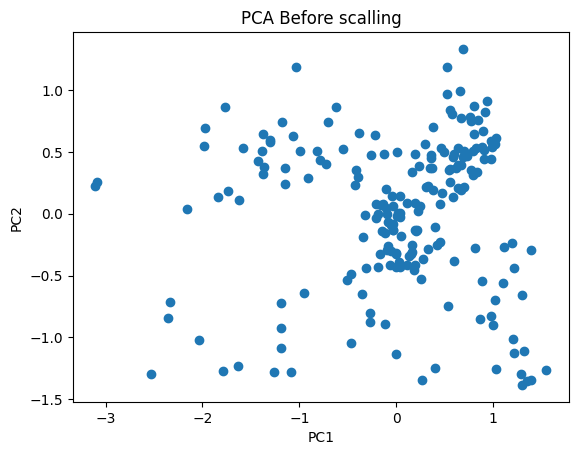

In [ ]:
pca1=PCA(n_components=2)
pca_result = pca1.fit_transform(Before_scaling)

plt.scatter(pca_result[:, 0], pca_result[:, 1])
plt.title("PCA Before scalling")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

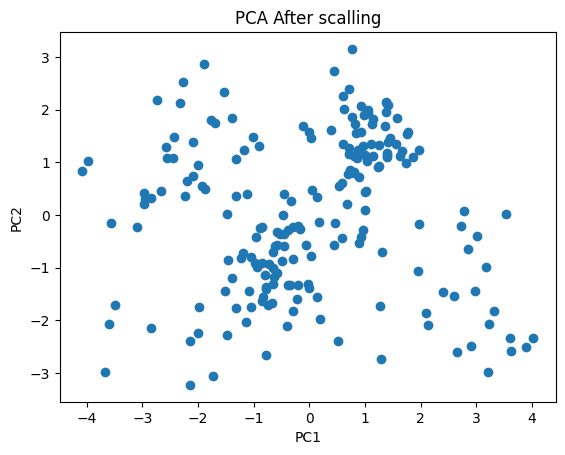

In [ ]:
pca2=PCA(n_components=2)
pca2_result = pca2.fit_transform(mall_df_scalled)

plt.scatter(pca2_result[:, 0], pca2_result[:, 1])
plt.title("PCA After scalling")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

**2D TSNE before and after PCA (visualization):**

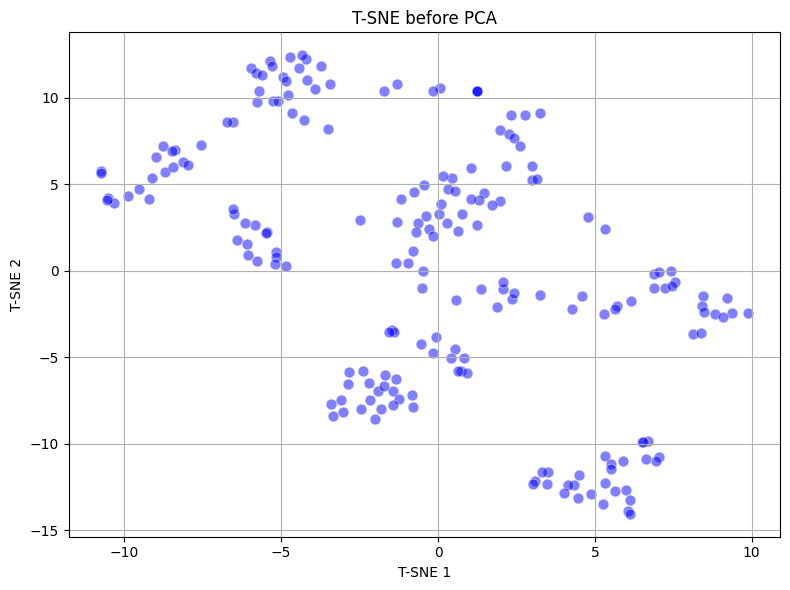

In [ ]:
from sklearn.manifold import TSNE
tsne = TSNE(n_components=2, perplexity=30 ,init='pca', max_iter=1000, random_state=42,method="barnes_hut")
x_tsne = tsne.fit_transform(mall_df_scalled)


plt.figure(figsize=(8, 6))
sns.scatterplot(x=x_tsne[:, 0], y=x_tsne[:, 1],
                color='blue', alpha=0.5, s=60)
plt.title("T-SNE before PCA")
plt.xlabel("T-SNE 1")
plt.ylabel("T-SNE 2")
plt.grid(True)
plt.tight_layout()
plt.show()

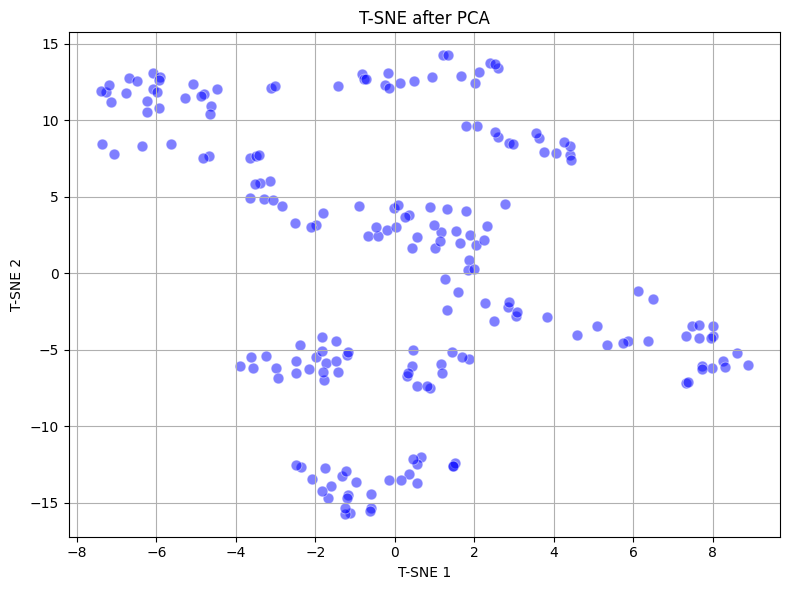

In [ ]:
from sklearn.manifold import TSNE
tsne = TSNE(n_components=2, perplexity=30 ,init='pca', max_iter=1000, random_state=42,method="barnes_hut")
x_tsne1 = tsne.fit_transform(x_pca)


plt.figure(figsize=(8, 6))
sns.scatterplot(x=x_tsne1[:, 0], y=x_tsne1[:, 1],
                color='blue', alpha=0.5, s=60)
plt.title("T-SNE after PCA")
plt.xlabel("T-SNE 1")
plt.ylabel("T-SNE 2")
plt.grid(True)
plt.tight_layout()
plt.show()

## Applying Random KMeans, KMeans++ and MiniBatchKMeans After PCA

In [ ]:
K = range(2,10)
best_k = None
best_score = -1

results = {
    'kmeans_random': {'inertia': [], 'silhouette': [], 'time': []},
    'kmeans_plus': {'inertia': [], 'silhouette': [], 'time': []},
    'mbkm': {'inertia': [], 'silhouette': [], 'time': []},
}

In [ ]:
results['kmeans_random']['inertia'] = []
results['kmeans_random']['silhouette']=[]
results['kmeans_random']['time']=[]
# Initializes three empty lists to add later on to the dictionary

for k in K:
    start = time.time()
    km_random = KMeans(n_clusters=k, init='random', n_init=10, random_state=42)
    labels_random = km_random.fit_predict(x_pca)
    duration = time.time() - start

    results['kmeans_random']['inertia'].append(km_random.inertia_)
    results['kmeans_random']['silhouette'].append(silhouette_score(x_pca, labels_random))
    results['kmeans_random']['time'].append(duration)
    sc0=silhouette_score(x_pca, labels_random)

    if sc0 > best_score:
         best_score = sc0
         best_k = k
         best_labels_random = labels_random
         # saves the best labels
         best_centroids_random =km_random.cluster_centers_
         #stores best centroids coordinates

print(f"Best K for KMeans with random initialization: {best_k}")

Best K for KMeans with random initialization: 8


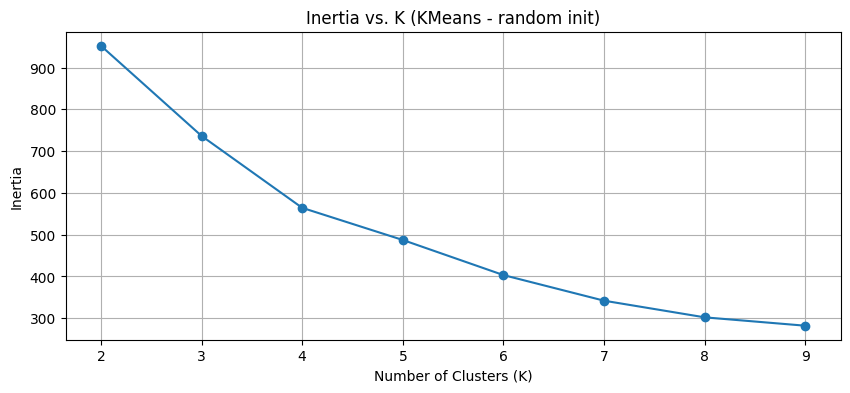

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(K, results['kmeans_random']['inertia'], marker='o')
plt.title("Inertia vs. K (KMeans - random init)")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.grid(True)
plt.show()

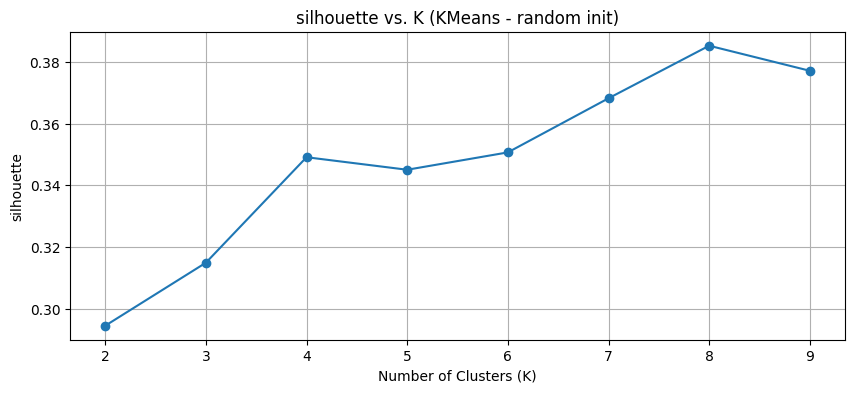

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(K, results['kmeans_random']['silhouette'], marker='o')
plt.title("silhouette vs. K (KMeans - random init)")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("silhouette")
plt.grid(True)
plt.show()

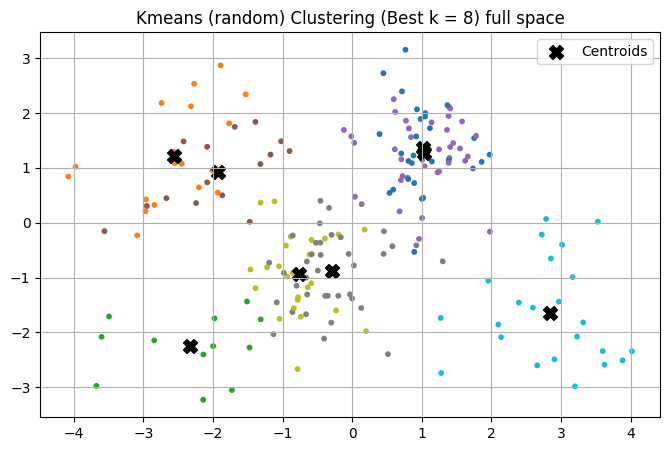

In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(x_pca[:, 0], x_pca[:, 1], c=best_labels_random, cmap='tab10', s=10)
plt.scatter(best_centroids_random[:, 0], best_centroids_random[:, 1], c='black', marker='X', s=100, label='Centroids')
plt.title(f'Kmeans (random) Clustering (Best k = {best_k}) full space')
plt.legend()
plt.grid(True)
plt.show()

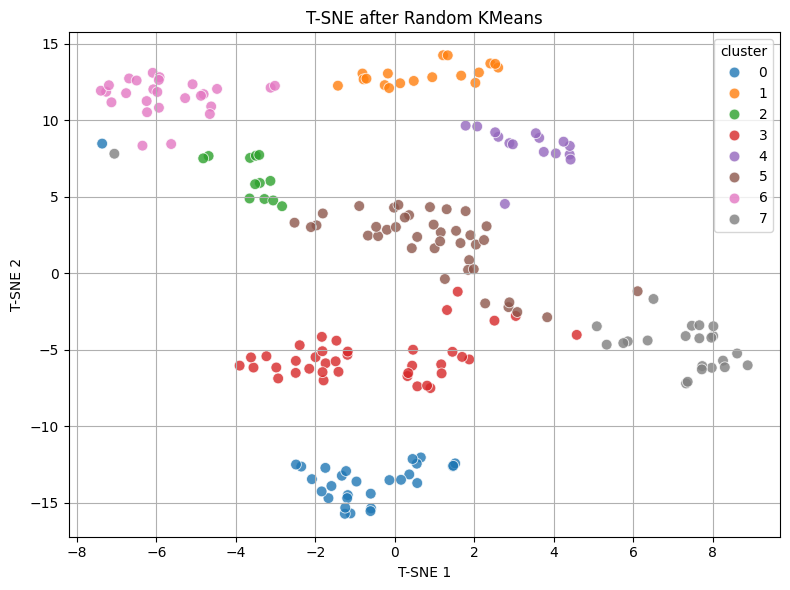

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=x_tsne1[:, 0], y=x_tsne1[:, 1], hue = best_labels_random, palette='tab10', s=60, alpha=0.8)
plt.title("T-SNE after Random KMeans")
plt.xlabel("T-SNE 1")
plt.ylabel("T-SNE 2")
plt.grid(True)
plt.tight_layout()
plt.legend(title="cluster")
plt.show()

In [ ]:
results['kmeans_plus']['inertia'] = []
results['kmeans_plus']['silhouette'] = []
results['kmeans_plus']['time'] = []

best_k_plus = None
best_score_plus = -1

for k in K:
    start = time.time()
    km_plus = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    labels_plus = km_plus.fit_predict(x_pca)
    duration = time.time() - start

    results['kmeans_plus']['inertia'].append(km_plus.inertia_)
    results['kmeans_plus']['silhouette'].append(silhouette_score(x_pca, labels_plus))
    results['kmeans_plus']['time'].append(duration)

    sc1=silhouette_score(x_pca, labels_plus)

    if sc1 > best_score_plus:
         best_score_plus = sc1
         best_k_plus = k
         best_labels_plus = labels_plus
         best_centroids_plus =km_plus.cluster_centers_

print(f"Best K for KMeans with k-means++ initialization: {best_k_plus}")

Best K for KMeans with k-means++ initialization: 9


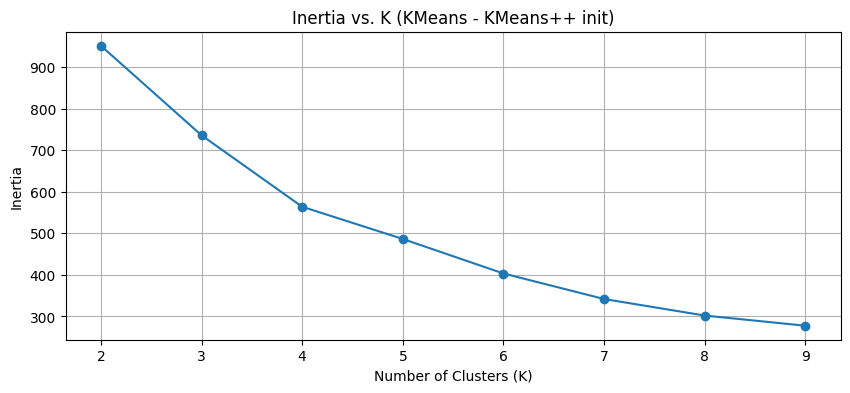

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(K, results['kmeans_plus']['inertia'], marker='o')
plt.title("Inertia vs. K (KMeans - KMeans++ init)")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.grid(True)
plt.show()

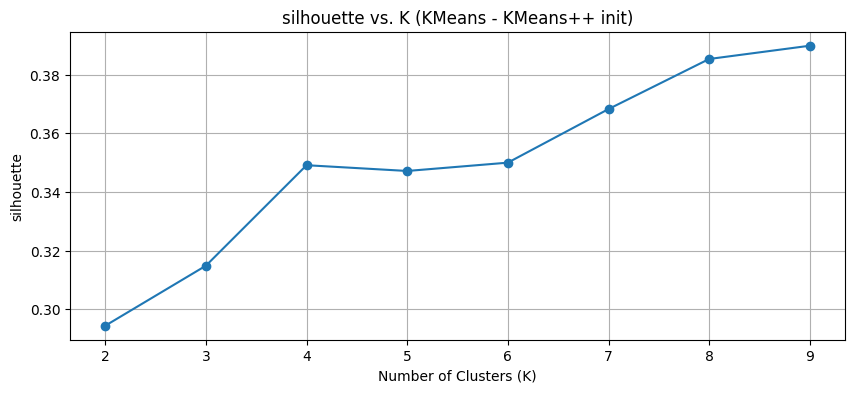

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(K, results['kmeans_plus']['silhouette'], marker='o')
plt.title("silhouette vs. K (KMeans - KMeans++ init)")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("silhouette")
plt.grid(True)
plt.show()

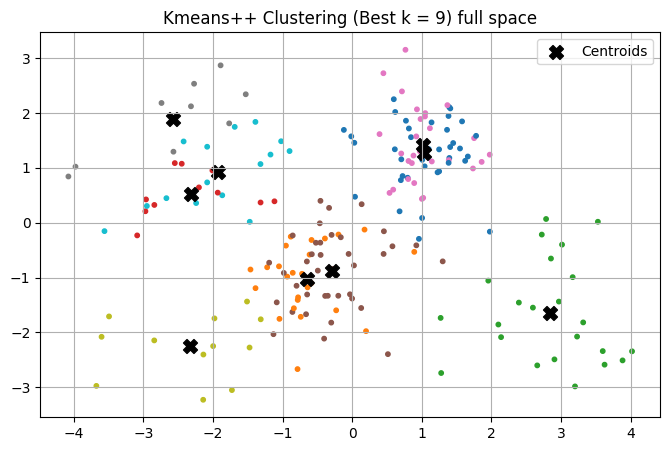

In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(x_pca[:, 0], x_pca[:, 1], c=best_labels_plus, cmap='tab10', s=10)
plt.scatter(best_centroids_plus[:, 0], best_centroids_plus[:, 1], c='black', marker='X', s=100, label='Centroids')
plt.title(f'Kmeans++ Clustering (Best k = {best_k_plus}) full space')
plt.legend()
plt.grid(True)
plt.show()

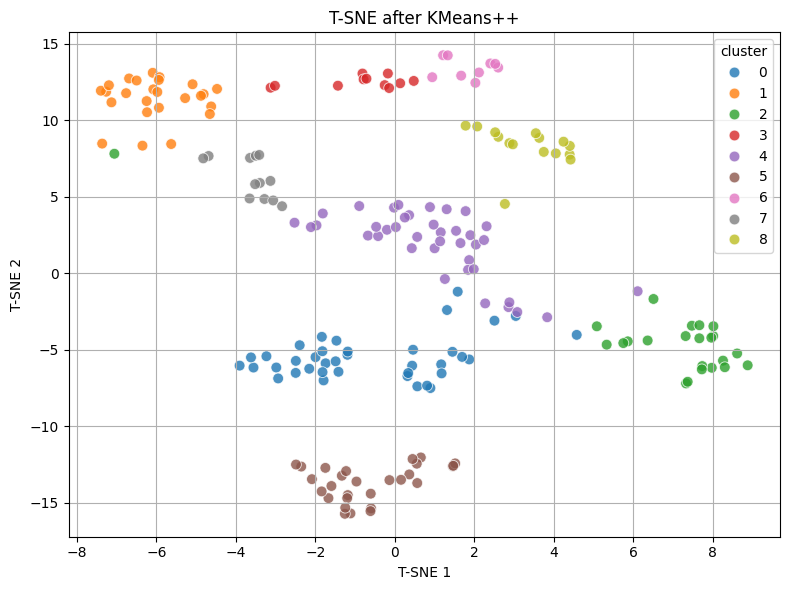

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=x_tsne1[:, 0], y=x_tsne1[:, 1], hue = best_labels_plus, palette='tab10', s=60, alpha=0.8)
plt.title("T-SNE after KMeans++")
plt.xlabel("T-SNE 1")
plt.ylabel("T-SNE 2")
plt.grid(True)
plt.tight_layout()
plt.legend(title="cluster")
plt.show()

In [ ]:
results['mbkm']['inertia'] = []
results['mbkm']['silhouette'] = []
results['mbkm']['time'] = []

best_k_mbkm = None
best_score_mbkm = -1

for k in K:
    start = time.time()
    mbkm = MiniBatchKMeans(n_clusters=k, batch_size=1000, random_state=42)
    labels_mbkm = mbkm.fit_predict(x_pca)
    duration = time.time() - start

    results['mbkm']['inertia'].append(mbkm.inertia_)
    results['mbkm']['silhouette'].append(silhouette_score(x_pca, labels_mbkm))
    results['mbkm']['time'].append(duration)

    sc=silhouette_score(x_pca, labels_mbkm)

    if sc > best_score_mbkm:
         best_score_mbkm = sc
         best_k_mbkm = k
         best_labels_mbkm = labels_mbkm
         best_centroids_mbkm = mbkm.cluster_centers_

print(f"Best K for MiniBatchKMeans: {best_k_mbkm}")

Best K for MiniBatchKMeans: 7


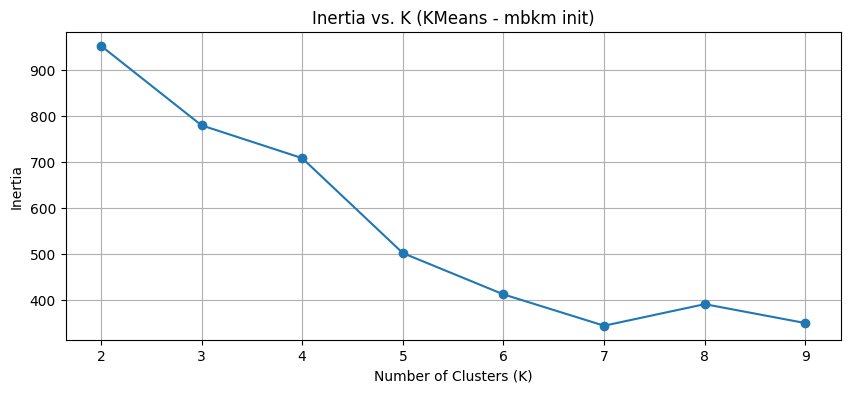

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(K, results['mbkm']['inertia'], marker='o')
plt.title("Inertia vs. K (KMeans - mbkm init)")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.grid(True)
plt.show()

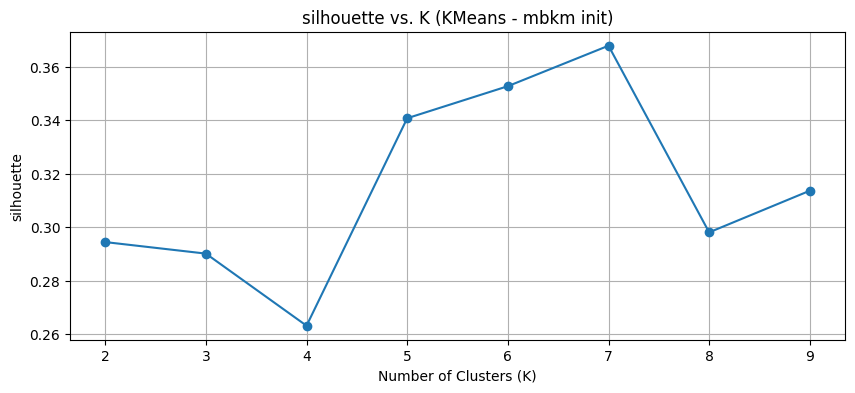

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(K, results['mbkm']['silhouette'], marker='o')
plt.title("silhouette vs. K (KMeans - mbkm init)")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("silhouette")
plt.grid(True)
plt.show()

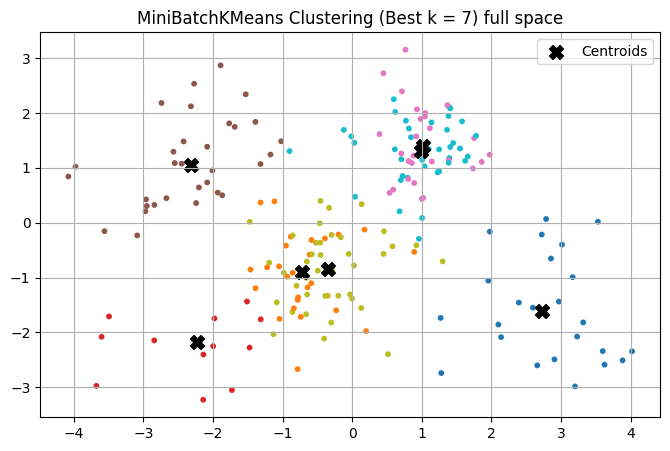

In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(x_pca[:, 0], x_pca[:, 1], c=best_labels_mbkm, cmap='tab10', s=10)
plt.scatter(best_centroids_mbkm[:, 0], best_centroids_mbkm[:, 1], c='black', marker='X', s=100, label='Centroids')
plt.title(f'MiniBatchKMeans Clustering (Best k = {best_k_mbkm}) full space')
plt.legend()
plt.grid(True)
plt.show()

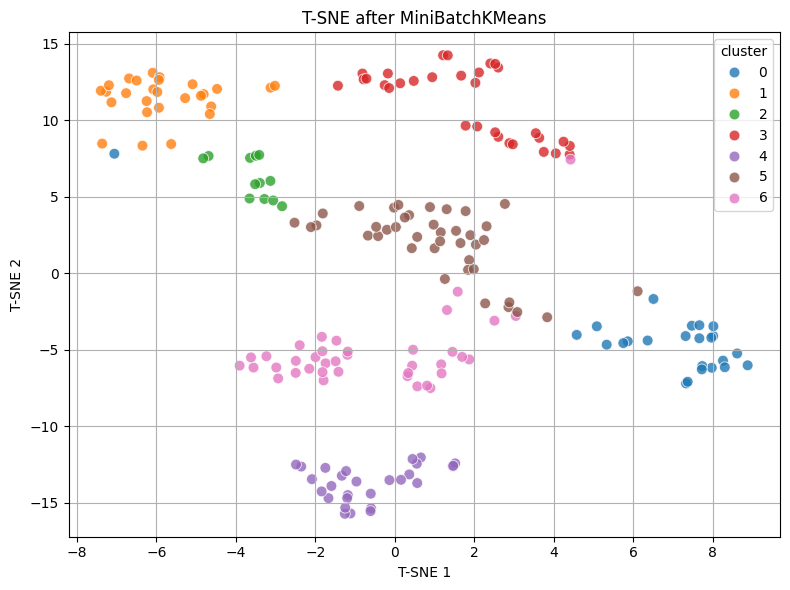

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=x_tsne1[:, 0], y=x_tsne1[:, 1], hue = best_labels_mbkm, palette='tab10', s=60, alpha=0.8)
plt.title("T-SNE after MiniBatchKMeans")
plt.xlabel("T-SNE 1")
plt.ylabel("T-SNE 2")
plt.grid(True)
plt.tight_layout()
plt.legend(title="cluster")
plt.show()

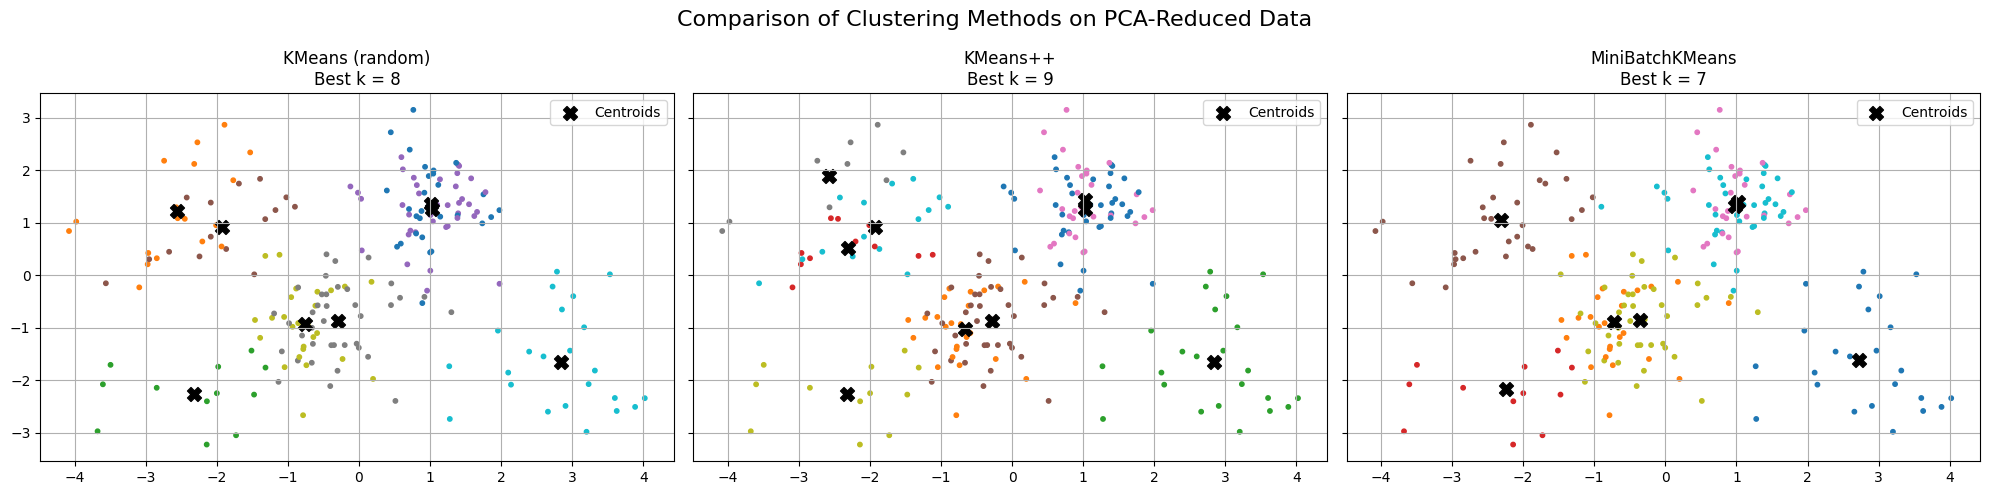

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(20, 5), sharex=True, sharey=True)

# --- KMeans (random init)
axes[0].scatter(x_pca[:, 0], x_pca[:, 1], c=best_labels_random, cmap='tab10', s=10)
axes[0].scatter(best_centroids_random[:, 0], best_centroids_random[:, 1], c='black', marker='X', s=100, label='Centroids')
axes[0].set_title(f'KMeans (random)\nBest k = {best_k}')
axes[0].legend()
axes[0].grid(True)

# --- KMeans++ init
axes[1].scatter(x_pca[:, 0], x_pca[:, 1], c=best_labels_plus, cmap='tab10', s=10)
axes[1].scatter(best_centroids_plus[:, 0], best_centroids_plus[:, 1], c='black', marker='X', s=100, label='Centroids')
axes[1].set_title(f'KMeans++\nBest k = {best_k_plus}')
axes[1].legend()
axes[1].grid(True)

# --- MiniBatchKMeans
axes[2].scatter(x_pca[:, 0], x_pca[:, 1], c=best_labels_mbkm, cmap='tab10', s=10)
axes[2].scatter(best_centroids_mbkm[:, 0], best_centroids_mbkm[:, 1], c='black', marker='X', s=100, label='Centroids')
axes[2].set_title(f'MiniBatchKMeans\nBest k = {best_k_mbkm}')
axes[2].legend()
axes[2].grid(True)

fig.suptitle('Comparison of Clustering Methods on PCA-Reduced Data', fontsize=16)
plt.tight_layout()
plt.show()


Comparing speeds and scores for all forms of KMeans

In [ ]:
kdf = pd.DataFrame({
    'K': list(range(2, 10)),

    'KMeans (Random) Inertia': results['kmeans_random']['inertia'],
    'KMeans (Random) Silhouette': results['kmeans_random']['silhouette'],
    'KMeans (Random) Time (s)': results['kmeans_random']['time'],

    'KMeans (k-means++) Inertia': results['kmeans_plus']['inertia'],
    'KMeans (k-means++) Silhouette': results['kmeans_plus']['silhouette'],
    'KMeans (k-means++) Time (s)': results['kmeans_plus']['time'],

    'MiniBatchKMeans Inertia': results['mbkm']['inertia'],
    'MiniBatchKMeans Silhouette': results['mbkm']['silhouette'],
    'MiniBatchKMeans Time (s)': results['mbkm']['time'],
})

kdf.head(10)

,K,KMeans (Random) Inertia,KMeans (Random) Silhouette,KMeans (Random) Time (s),KMeans (k-means++) Inertia,KMeans (k-means++) Silhouette,KMeans (k-means++) Time (s),MiniBatchKMeans Inertia,MiniBatchKMeans Silhouette,MiniBatchKMeans Time (s)
0,2,952.133083,0.294436,0.006714,952.133083,0.294436,0.014510,953.029467,0.294436,0.009804
1,3,736.302309,0.314881,0.007286,736.302309,0.314881,0.011693,779.746992,0.290124,0.005534
2,4,564.152317,0.349113,0.008092,564.152317,0.349113,0.012972,708.311942,0.263154,0.005753
3,5,487.167029,0.345052,0.008703,486.531198,0.347152,0.015287,501.695241,0.340757,0.004636
4,6,403.181863,0.350684,0.007435,403.349153,0.349983,0.016888,411.780531,0.352747,0.005889
5,7,341.859666,0.368236,0.007622,341.859666,0.368236,0.017644,343.556396,0.367879,0.005121
6,8,302.021661,0.385297,0.007261,302.021661,0.385297,0.029611,390.496331,0.298077,0.005373
7,9,281.994702,0.377167,0.009341,277.533519,0.389817,0.020417,349.290139,0.313646,0.006490


In [ ]:
print("~ kmeans (random) with best k=8 :\n")
print("Inertia:", kdf.iloc[6]["KMeans (Random) Inertia"])
print("Silhouette:", kdf.iloc[6]["KMeans (Random) Silhouette"])
print("Time:", kdf.iloc[6]["KMeans (Random) Time (s)"])
print("-------------------------------")
print("~ kmeans++ with best k=9 :\n")
print("Inertia:", kdf.iloc[7]['KMeans (k-means++) Inertia'])
print("Silhouette:", kdf.iloc[7]['KMeans (k-means++) Silhouette'])
print("Time:", kdf.iloc[7]['KMeans (k-means++) Time (s)'])
print("-------------------------------")
print("~ Minibatchkmeans with best k=7 :\n")
print("Inertia:", kdf.iloc[5]['MiniBatchKMeans Inertia'])
print("Silhouette:", kdf.iloc[5]['MiniBatchKMeans Silhouette'])
print("Time:", kdf.iloc[5]['MiniBatchKMeans Time (s)'])

~ kmeans (random) with best k=8 :

Inertia: 302.021660613237
Silhouette: 0.38529711905009706
Time: 0.007261037826538086
-------------------------------
~ kmeans++ with best k=9 :

Inertia: 277.5335186197652
Silhouette: 0.3898170726443043
Time: 0.020416736602783203
-------------------------------
~ Minibatchkmeans with best k=7 :

Inertia: 343.5563963652517
Silhouette: 0.36787904493455387
Time: 0.005120754241943359


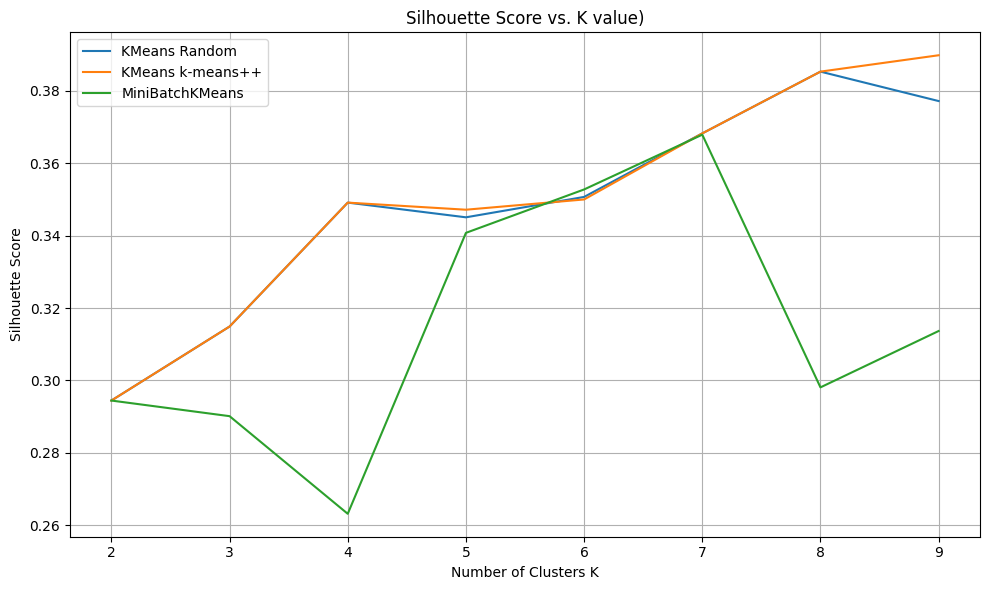

-----------------------------
look for the highest point to know the best num of k (highest silhouette)


In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(kdf['K'], kdf['KMeans (Random) Silhouette'], label='KMeans Random')
plt.plot(kdf['K'], kdf['KMeans (k-means++) Silhouette'], label='KMeans k-means++')
plt.plot(kdf['K'], kdf['MiniBatchKMeans Silhouette'], label='MiniBatchKMeans')
plt.xlabel('Number of Clusters K')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score vs. K value)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
print("-----------------------------")
print("look for the highest point to know the best num of k (highest silhouette)")

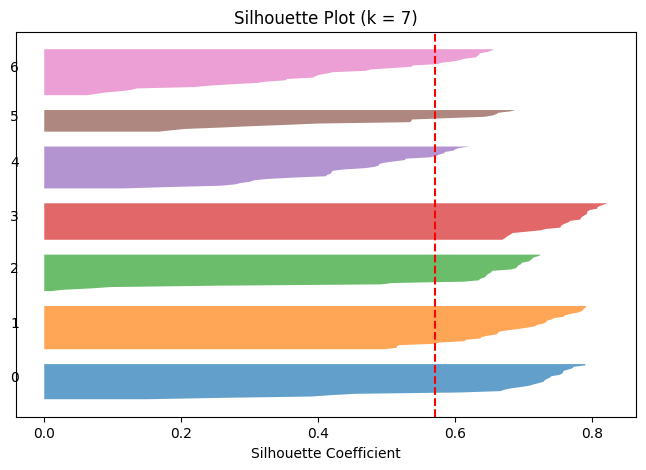

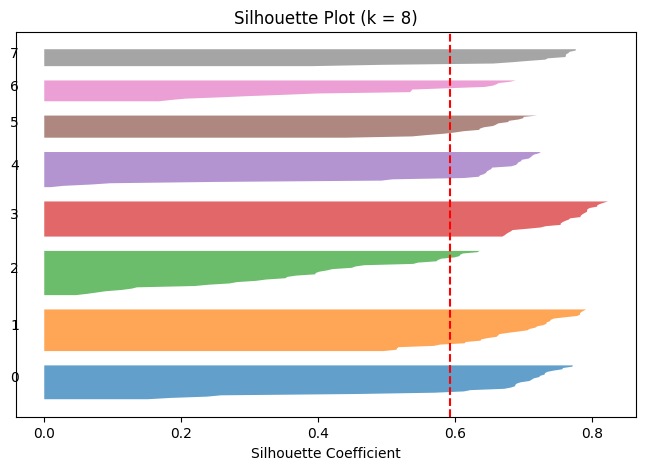

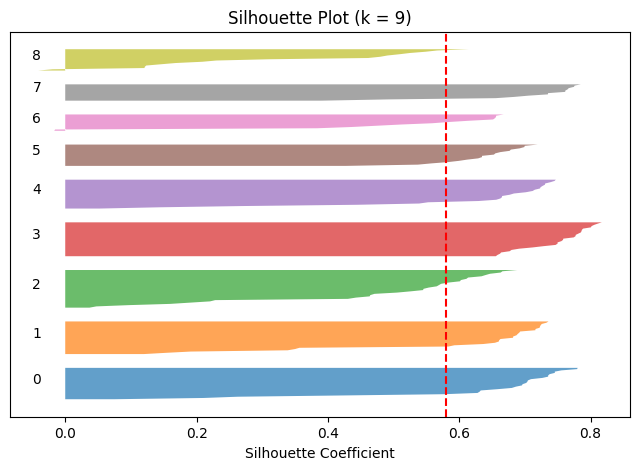

In [ ]:
for k in [7,8,9]:
    labels = KMeans(n_clusters=k, random_state=42).fit_predict(x_tsne)
    sil_vals = silhouette_samples(x_tsne, labels)
    y = 10

    fig, ax = plt.subplots(figsize=(8, 5))
    for i in range(k):
        v = np.sort(sil_vals[labels == i])
        ax.fill_betweenx(np.arange(y, y + len(v)), 0, v, alpha=0.7)
        ax.text(-0.05, y + len(v)/2, str(i))
        y += len(v) + 10

    ax.axvline(np.mean(sil_vals), color='red', linestyle='--')
    ax.set_title(f'Silhouette Plot (k = {k})')
    ax.set_xlabel('Silhouette Coefficient')
    ax.set_yticks([])
    plt.show()

In [ ]:
eps_values = [0.5, 1.0, 1.5, 2.0, 2.6, 2.8, 2.10]
min_samples_list = [3, 5, 9, 15]

results = []

for eps in eps_values:
    for min_samples in min_samples_list:
        db= DBSCAN(eps= eps, min_samples= min_samples)
        labels= db.fit_predict(x_pca)

        # Counting clusters
        if -1 in labels:
            n_clusters= len(set(labels)) - 1
        else:
            n_clusters = len(set(labels))

        noise = np.sum(labels == -1) / len(labels)

        # Only compute silhouette if we have at least 2 clusters and < all noise
        if n_clusters >= 2:
            sil = round(silhouette_score(x_pca, labels), 3)
        else:
            sil = 'N/A'

        results.append({
            'eps': eps,
            'min_samples': min_samples,
            'clusters': n_clusters,
            'noise_ratio': round(noise, 2),
            'silhouette': sil
        })

df = pd.DataFrame(results)

In [ ]:
best_row = df[df['silhouette'] != 'N/A'].sort_values(by='silhouette', ascending=False).iloc[0]

best_eps = best_row['eps']
best_min_samples = int(best_row['min_samples'])

model = DBSCAN(eps=best_eps, min_samples=best_min_samples)
labels = model.fit_predict(x_tsne)

unique_l= np.unique(labels)
n_clusters = len(unique_l[unique_l != -1])
n_noise = np.sum(labels == -1)

print(f"Number of clusters: {n_clusters}")
print(f"Number of noise points: {n_noise}")

Number of clusters: 9
Number of noise points: 4


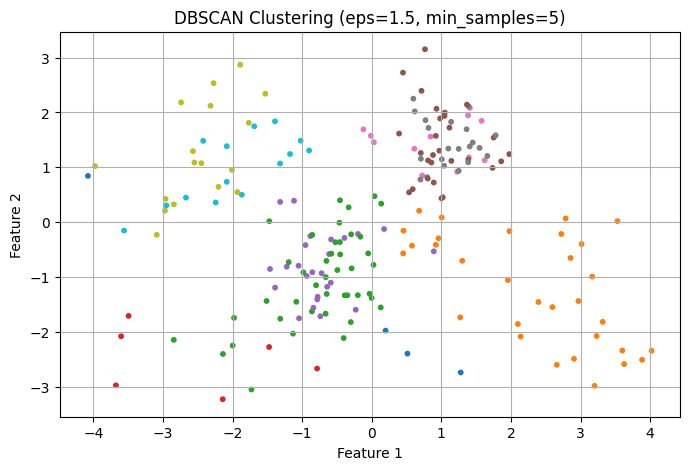

--------------------------------
 The grey points are outliers
--------------------------------


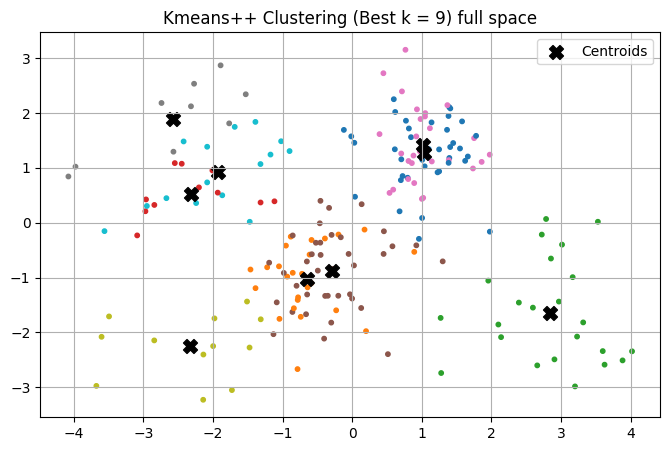

In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(x_pca[:, 0], x_pca[:, 1], c=labels, cmap='tab10', s=10)
plt.title(f'DBSCAN Clustering (eps={best_eps}, min_samples={best_min_samples})')
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.grid(True)
plt.show()
print("--------------------------------")
print(" The grey points are outliers")
print("--------------------------------")
plt.figure(figsize=(8, 5))
plt.scatter(x_pca[:, 0], x_pca[:, 1], c=best_labels_plus, cmap='tab10', s=10)
plt.scatter(best_centroids_plus[:, 0], best_centroids_plus[:, 1], c='black', marker='X', s=100, label='Centroids')
plt.title(f'Kmeans++ Clustering (Best k = {best_k_plus}) full space')
plt.legend()
plt.grid(True)
plt.show()

**While KMeans++ gave compact clusters, DBSCAN was able to detect outliers and handled irregular cluster shapes better. Both results provide useful insights depending on the analysis focus.**